In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import matplotlib.pyplot as plt
from matplotlib import colors

import sys
sys.path.append("../src")

import netket as nk

from netket.experimental.dynamics import RK45
from callbacks import (
    get_tdvp_monitor_callback,
    get_umbrella_monitor_callback,
    get_parameter_save_callback
)
from logger import Logger


W0212 12:25:17.374215 1111245 platform_util.cc:218] unable to create StreamExecutor for CUDA:0: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


RuntimeError: Unable to initialize backend 'cuda': INTERNAL: no supported devices found for platform CUDA (you may need to uninstall the failing plugin package, or set JAX_PLATFORMS=cpu to skip this backend.)

In [19]:
L=3
N = L**2
alpha = 1
hilbert = nk.hilbert.Spin(s=1 / 2, N=N)
graph = nk.graph.Hypercube(length=L, n_dim=2, pbc=True)
hamiltonian = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=-1., J=-10.)
e, gs = nk.exact.lanczos_ed(hamiltonian, compute_eigenvectors=True)
print(e)

[-180.11250586]


# Exact dynamics

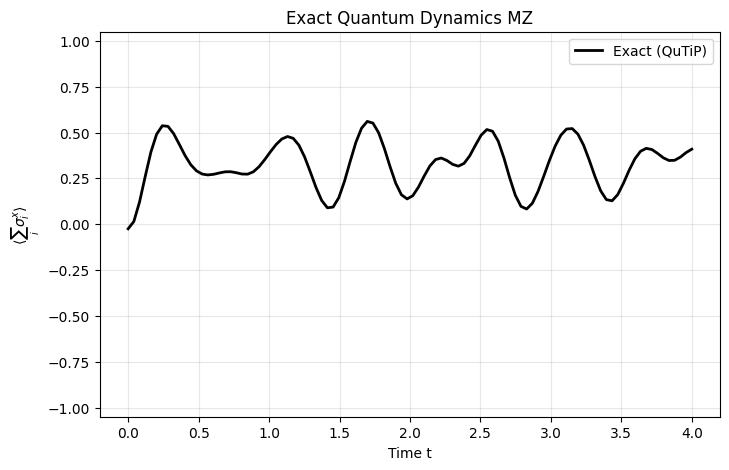

Initial parity: -0.025003
Final parity: 0.409379


In [18]:
import qutip as qt
import numpy as np
from netket.operator.spin import sigmax, sigmaz

J=1.
hc = 3.044 * J
hamiltonian_quench = nk.operator.IsingJax(hilbert=hilbert, graph=graph, h=hc, J=-J)

# Get the Hamiltonian matrix from netket
H_matrix = hamiltonian_quench.to_dense()

# Convert to QuTiP Qobj
H_qutip = qt.Qobj(H_matrix)

# Get initial state from vstate
psi0_array = gs
psi0_qutip = qt.Qobj(psi0_array)
psi0_qutip = psi0_qutip.unit()  # Normalize

# Create parity operator (product of all Z_i)
# Convert netket operator to matrix
mx = sum([sigmax(hilbert, i) for i in graph.nodes()]) / graph.n_nodes
mx = mx.to_jax_operator()
obs = mx.to_dense()
# Pz = nk.operator.PauliStringsJax(hilbert, "Z" * N, -1.0)
# obs = Pz.to_dense()

# Convert to QuTiP
Z_parity_qutip = qt.Qobj(obs)

# Time evolution parameters
T = 4
times_exact = np.linspace(0.0, T, 100)

# Evolve the state and calculate expectation values
parity_exact = []
for t in times_exact:
    # Evolve state
    psi_t = (-1j * H_qutip * t).expm() * psi0_qutip
    # Calculate expectation value
    par = qt.expect(Z_parity_qutip, psi_t)
    parity_exact.append(par)

# Plot the exact dynamics
plt.figure(figsize=(8, 5))
plt.plot(times_exact, np.real(parity_exact), "k-", linewidth=2, label="Exact (QuTiP)")
plt.xlabel("Time t")
plt.ylabel(r"$\langle \sum_i \sigma^x_i \rangle$")
plt.title("Exact Quantum Dynamics MZ")
plt.ylim([-1.05, 1.05])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Initial parity: {np.real(parity_exact[0]):.6f}")
print(f"Final parity: {np.real(parity_exact[-1]):.6f}")

In [77]:
def plot(save_path):
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())

    fig, axs = plt.subplots(2, 3, figsize=(12, 8))
    (ax_snr, ax_snrF, ax_dt) = axs[0]
    (ax_z, ax_ess, ax_rsq) = axs[1]
    ax_z.plot(logger.data["t"]["values"], logger.data["parity"]["Mean"])
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"Parity")

    x_vals = logger.data["t"]["values"]
    ess_vals = logger.data["ess_bridge"]["values"]
    q_vals = logger.data["q_bridge"]["values"]
    if ess_vals and q_vals:
        ax_right = ax_ess.twinx()
        (line1,) = ax_ess.plot(x_vals, ess_vals, color="tab:blue", label="ESS (bridge)")
        # Also plot max_weight_over_mean on left axis
        (line2,) = ax_right.plot(x_vals, q_vals, color="tab:orange", label="q (bridge)")
        target_ess = 0.1
        ax_right.axhline(
            target_ess,
            color="tab:blue",
            linestyle="--",
            linewidth=1,
            alpha=0.7,
            label=f"ess target = {target_ess:1.2f}",
        )

        ax_ess.set_xlabel("Step")
        ax_ess.set_ylabel("ESS (bridge)", color="tab:blue")
        ax_right.set_ylabel("q (bridge)", color="tab:orange")
        ax_ess.set_ylim(-0.05, 1.05)
        ax_right.set_ylim(0.0, 1.05)
        ax_ess.grid(True, alpha=0.3)
        ax_ess.set_title("Bridge ESS, q")

        lines = [line1, line2]
        labels = [l.get_label() for l in lines]
        # Include max_weight_over_mean if present
        ax_ess.legend(
            lines + [ax_right.lines[-1]],
            labels + [f"ess target = {target_ess:1.2f}"],
            loc="best",
        )

    # Top-left: SNR (eigenbasis) sorted curves with log y; add median and min lines
    snr_len = len(logger.data.get("snr", {}).get("values", []))
    cmap_snr = plt.get_cmap("viridis")
    # Normalize step index to [0,1] for colorbar
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.)
    for i in range(snr_len):
        snr_data = np.array(logger.data["snr"]["values"][i]).flatten()
        frac = 0.0 if snr_len <= 1 else i / 20
        ax_snr.plot(np.sort(snr_data), color=cmap_snr(norm_frac(frac)))
    # Summary lines from monitor
    snr_med_series = logger.data.get("snr_med", {}).get("values", [])
    snr_min_series = logger.data.get("snr_min", {}).get("values", [])
    if len(snr_med_series) > 0:
        ax_snr.axhline(
            np.array(snr_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    ax_snr.set_xlabel(r"Mode index $k$")
    ax_snr.set_ylabel("SNR (eigenbasis)")
    ax_snr.set_title(rf"SNR($\rho_k$) over time")
    ax_snr.set_yscale("log")
    # ax_snr.set_ylim([1e-6, 1e7])
    ax_snr.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    cmap_snr = plt.get_cmap('viridis')
    norm_frac = colors.Normalize(vmin=0.0, vmax=1.0)
    sm_snr = plt.cm.ScalarMappable(cmap=cmap_snr, norm=norm_frac)
    sm_snr.set_array([])
    fig.colorbar(sm_snr, ax=ax_snr, pad=0.02, label="t")

    # Top-middle: SNR(F) sorted curves with log y; add median and min lines
    snrF_len = len(logger.data.get("snr_F", {}).get("values", []))
    cmap_snrF = plt.get_cmap("viridis")
    for i in range(snrF_len):
        snr_F_data = np.array(logger.data["snr_F"]["values"][i]).flatten()
        # print(snr_F_data)
        frac = 0.0 if snrF_len <= 1 else i / 20
        ax_snrF.plot(np.sort(snr_F_data), color=cmap_snrF(norm_frac(frac)))
    snrF_med_series = logger.data.get("snrF_med", {}).get("values", [])
    snrF_min_series = logger.data.get("snrF_min", {}).get("values", [])
    if len(snrF_med_series) > 0:
        ax_snrF.axhline(
            np.array(snrF_med_series)[-1],
            color="black",
            linestyle="--",
            label="median",
        )
    # if len(snrF_min_series) > 0:
    #     ax_snrF.axhline(np.array(snrF_min_series)[-1], color="gray", linestyle=":", label="min")
    ax_snrF.set_xlabel(r"Parameter index $k$")
    ax_snrF.set_ylabel("SNR(F)")
    ax_snrF.set_title(rf"SNR(F) over time")
    ax_snrF.set_yscale("log")
    # ax_snrF.set_ylim([1e-2, 1e2])
    ax_snrF.legend(loc="best")
    # Add colorbar for normalized step [0,1]
    sm_snrF = plt.cm.ScalarMappable(cmap=cmap_snrF, norm=norm_frac)
    sm_snrF.set_array([])

    ax_dt.plot(x_vals, logger.data["dt"]["values"])
    ax_dt.set_xlabel("Step")
    ax_dt.set_ylabel("dt")
    ax_dt.set_title("Adaptive time step")
    ax_dt.set_yscale("log")
    ax_dt.set_ylim([1e-5, 5e-2])

    
    # Add cumulative r_squared on right axis
    t_vals = logger.data["t"]["values"]
    r_sq = logger.data["r_squared"]["values"]
    print(r_sq)
    ax_rsq.plot(t_vals, r_sq, color="tab:purple")
    ax_rsq.set_xlabel("t")
    ax_rsq.set_ylabel("r_squared", color="tab:purple")
    ax_rsq.set_title("Generator r_squared vs time")
    r_sq_arr = np.array(r_sq, dtype=float)
    if np.any(np.isfinite(r_sq_arr) & (r_sq_arr > 0.0)):
        ax_rsq.set_yscale("log")

    ax_rsq_right = ax_rsq.twinx()
    r_sq_arr = np.array(r_sq, dtype=float)
    r_sq_cum = np.nancumsum(r_sq_arr)
    ax_rsq_right.plot(
        t_vals, r_sq_cum, color="tab:green", label="cumulative r_squared"
    )
    ax_rsq_right.set_ylabel("cumulative r_squared", color="tab:green")
    ax_rsq_right.tick_params(axis="y")
    ax_rsq_right.set_yscale("log")

    plt.tight_layout()
    plt.show()

## Standard Dynamics

In [ ]:
from schmitt_tdvp import TDVPSchmitt


def fit(n_samples_tvmc):    
    T = 0.5
    save_times = np.linspace(0.0, T, 40)
    exp_name = f"fixed_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook
    
    save_path = f"./data/TFIM_{N}_parity/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
        else:
            t0 = logger["t"]["values"][-1]
            dt = logger["dt"]["values"][-1]
    else:
        t0 = 0.0
        dt = 1e-4
        
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    vstate = get_vstate(n_samples_tvmc)
    for i in range(100):
        vstate.sample()
    print(vstate.expect(sigma_z))
    callbacks = []
    callbacks.append(measure_parity)
    tdvp_monitor_callback = get_tdvp_monitor_callback(save_times, save_path)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(tdvp_monitor_callback)
    integrator = RK45(dt, adaptive=True, rtol=1e-4, dt_limits=(1e-4, 1e-2))
    tvmc_kwargs = {}
    driver = TDVPSchmitt(
        hamiltonian,
        vstate,
        integrator,
        t0=0,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
        **tvmc_kwargs,
    )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)

In [69]:
fit(2**11)


File not found
1.00e+00+0.00e+00j ± nan [σ²=0.0e+00]


 21%|██        | 0.10/0.50 [06:16<23:56, 3.63ks/it, n=783, Generator=0.02+0.06j ± 0.12 [σ²=3.1e+01]]    


KeyboardInterrupt: 

Restored: True
[array(nan), array(1.27198745e-06), array(2.9297007e-06), array(1.18108148e-06), array(7.3183299e-06), array(1.57559756e-06), array(3.99545843e-06), array(1.35659287e-06), array(1.89380406e-06), array(2.55176033e-06), array(1.12600165e-05), array(2.68185964e-06), array(1.76380359e-06), array(1.99869721e-06), array(3.76684424e-06), array(1.74366643e-06), array(3.726464e-06), array(9.62252214e-06), array(1.2464303e-05), array(2.49251545e-06), array(5.75169523e-06), array(2.81984698e-06), array(5.47282962e-06), array(5.12100021e-06), array(8.07553239e-06), array(5.70048002e-06), array(3.72249302e-06), array(8.18508746e-06), array(1.90335257e-05), array(6.41369163e-06), array(4.85287121e-06), array(2.73587286e-06), array(1.34004705e-05), array(5.23156756e-06), array(4.33860414e-06), array(5.46532336e-06), array(1.24548002e-05), array(5.32717176e-06), array(5.71865771e-06), array(3.89742823e-06), array(1.8550404e-05), array(5.56586215e-06), array(2.71899909e-05), array(5.1255

/tmp/ipykernel_560682/3055909344.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_z.legend()


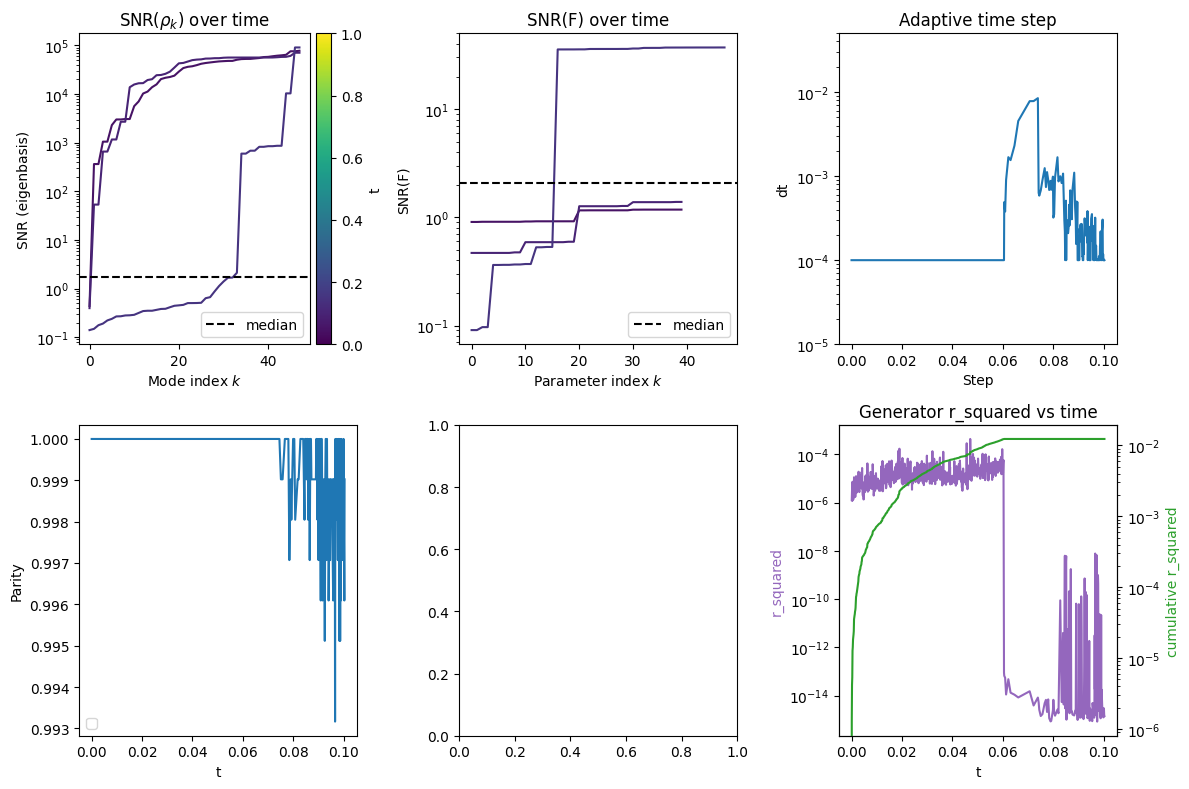

File not found
Restored: False
Restored: True
Restored: True
File not found
Restored: False
File not found
Restored: False
File not found
Restored: False


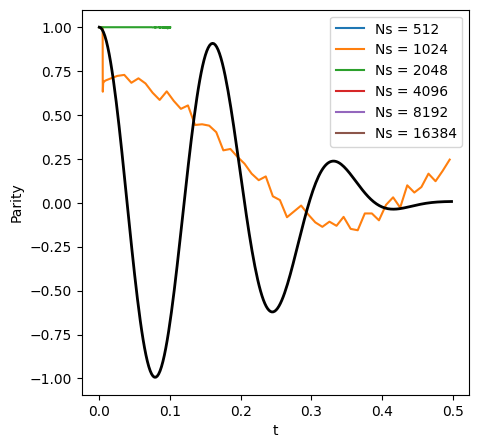

In [87]:
n_samples_tvmc = 2**11
N=4
exp_name = f"fixed_{n_samples_tvmc}/"
save_path = f"./data/TFIM_{N}_parity/{exp_name}"
plot(save_path)

fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"fixed_{n_samples}"
    save_path = f"./data/TFIM_{N}_parity/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())
    
    ax_z.plot(logger.data["t"]["values"], logger.data["parity"]["Mean"], label = f"Ns = {n_samples}")
    ax_z.set_xlabel("t")
    ax_z.legend()
    ax_z.set_ylabel(r"Parity")
ax_z.plot(times_exact, np.real(parity_exact), 'k-', linewidth=2, label='Exact')



In [83]:
from schmitt_tdvp_bridge import TDVPSchmittBridge

def fit_bridge(n_samples_tvmc):
    T = 0.5
    save_times = np.linspace(0.0, T, 40)
    exp_name = f"bridge_{n_samples_tvmc}"
    # Make sure we always start with the same state in notebook

    save_path = f"./data/TFIM_{N}_parity/{exp_name}/"

    logger = Logger(path=save_path, fields=fields_to_track)
    if logger.restore():
        if logger.done:
            print("Data exists, skipping...")
            return
        else:
            t0 = logger["t"]["values"][-1]
            dt = logger["dt"]["values"][-1]
    else:
        t0 = 0.0
        dt = 1e-5
    if not os.path.exists(save_path):
        os.makedirs(save_path)

    vstate = get_vstate(n_samples_tvmc)

    for i in range(1000):
        vstate.sample()
    
    callbacks = [ ]
    callbacks.append(measure_parity)
    tdvp_monitor_callback = get_umbrella_monitor_callback(save_times, save_path)
    callbacks.append(tdvp_monitor_callback)
    parameter_save_callback = get_parameter_save_callback(save_times, logger)
    callbacks.append(parameter_save_callback)

    integrator = RK45(dt, adaptive=True, rtol=1e-4, dt_limits=(1e-5, 1e-2))
    tvmc_kwargs = {}
    driver = TDVPSchmittBridge(
        hamiltonian,
        vstate,
        integrator,
        t0=t0,
        q=0.2,
        holomorphic=False,
        snr_atol=2,
        rcond=1e-14,
        rcond_smooth=1e-10,
            **tvmc_kwargs,
        )

    driver.run(
        T,
        out=logger,
        callback = callbacks,
        show_progress=True,
        timeit=True,
    )
    logger.flush(vstate, done=True)



In [84]:
fit_bridge(2**11)

File not found


  0%|          | 0.00/0.50 [00:00<?, ?it/s, n=0, Generator=None]

Saved parameters...


  2%|▏         | 0.01/0.50 [08:02<8:29:44, 62.1ks/it, n=765, Generator=0.34+26.25j ± 0.48 [σ²=4.7e+02]] 


KeyboardInterrupt: 

Restored: True
[array(nan), array(1.02885309e-06), array(5.52432404e-07), array(4.49846722e-07), array(7.26078608e-07), array(5.39023347e-07), array(6.12698184e-07), array(7.52755668e-07), array(6.22823978e-06), array(3.37779939e-14), array(4.09015078e-14), array(2.5759767e-14), array(1.5548729e-14), array(2.47943881e-14), array(3.98414425e-15), array(2.59012664e-15), array(1.62686596e-15), array(2.82756097e-10), array(1.94758816e-15), array(1.79148354e-15), array(9.84702512e-13), array(1.61793955e-15), array(1.43853707e-13), array(5.47273459e-14), array(5.43624482e-12), array(3.73653325e-14), array(2.69787659e-14), array(6.05541087e-14), array(2.2836145e-14), array(2.34593851e-15), array(3.99189224e-14), array(1.81797264e-15), array(2.026207e-15), array(1.47485201e-15), array(1.01796722e-15), array(1.33834331e-15), array(8.87050892e-16), array(9.193699e-16), array(1.21846816e-15), array(1.82671073e-15), array(2.05464547e-15), array(1.14561372e-15), array(1.17056478e-15), array(1.06012

/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/mnt/home/rwiersema/blurred_sampling/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
/tmp/ipykernel_560682/3055909344.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_z.legend()


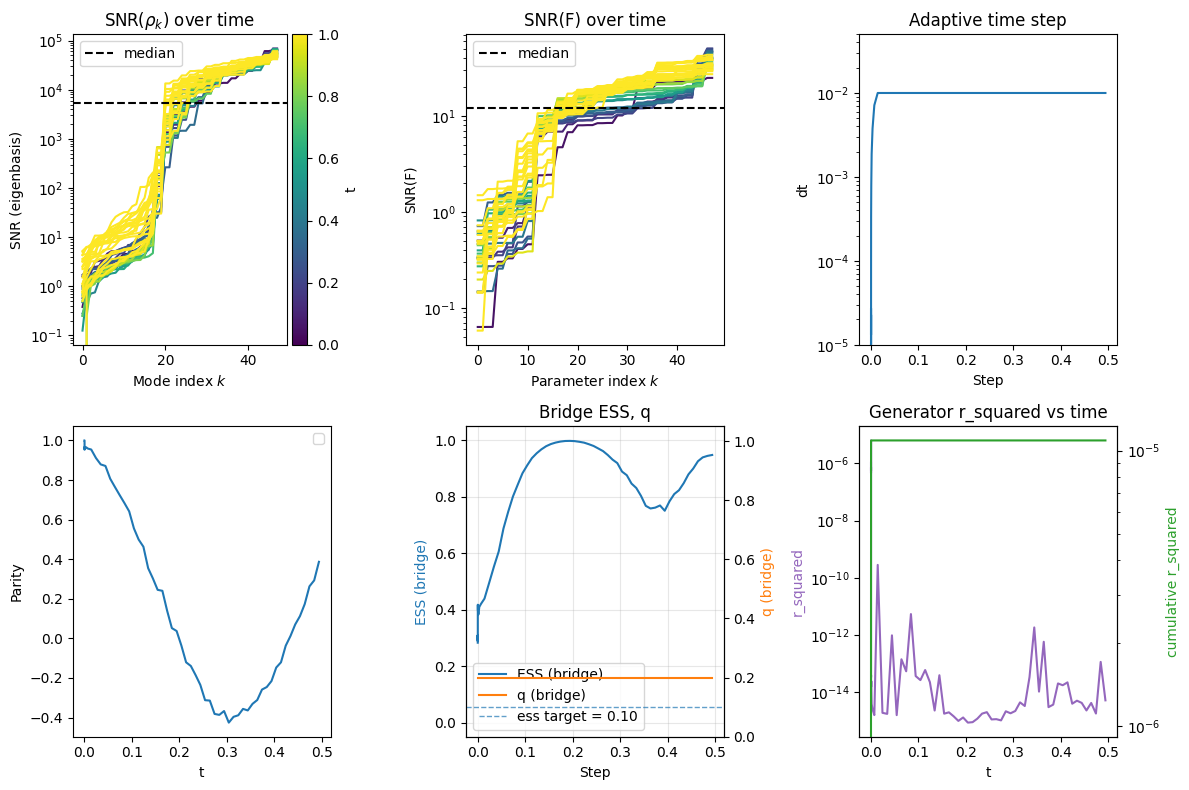

File not found
Restored: False
Restored: True
Restored: True
File not found
Restored: False
File not found
Restored: False
File not found
Restored: False


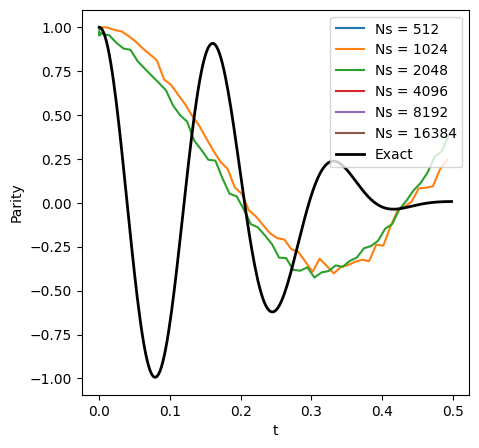

In [ ]:
n_samples_tvmc = 2**11
exp_name = f"bridge_{n_samples_tvmc}/"
save_path = f"./data/TFIM_{N}_parity/{exp_name}"
plot(save_path)

fig, ax_z = plt.subplots(1, 1, figsize=(5, 5))
for n_samples in n_samples_list:
    exp_name = f"bridge_{n_samples}"
    save_path = f"./data/TFIM_{N}_parity/{exp_name}/"
    logger = Logger(path=save_path, fields=fields_to_track)
    print("Restored:", logger.restore())    
    ax_z.plot(logger.data["t"]["values"], logger.data["parity"]["Mean"], label = f"Ns = {n_samples}", zorder=-1)
    ax_z.set_xlabel("t")
    ax_z.set_ylabel(r"Parity")
ax_z.plot(times_exact, np.real(parity_exact), 'k-', linewidth=2, label='Exact')
ax_z.legend()
plt.show()
